# Part 3

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from final.lsm import lsm_price

## b)

### ii. Computational Examples

First we set up some simulation parameters for the GBM.

In [2]:
S0 = 100
r = 0.04
sigma = 0.4
T = 1.0
mu = 0.04
n = 50 
sim_counts = [1000, 5000, 10000, 20000]

I start by demonstrating the usage of antithetic sampling on an ATM put.

,N,Price SMC,SE SMC,Price Anti,SE Anti,Variance Reduction
0,1000,14.432801,0.498928,14.542707,0.230356,4.691144
1,5000,14.117224,0.214771,14.106642,0.095179,5.091749
2,10000,14.196188,0.151092,14.091223,0.067925,4.947988
3,20000,14.054965,0.105974,14.115744,0.048760,4.723523


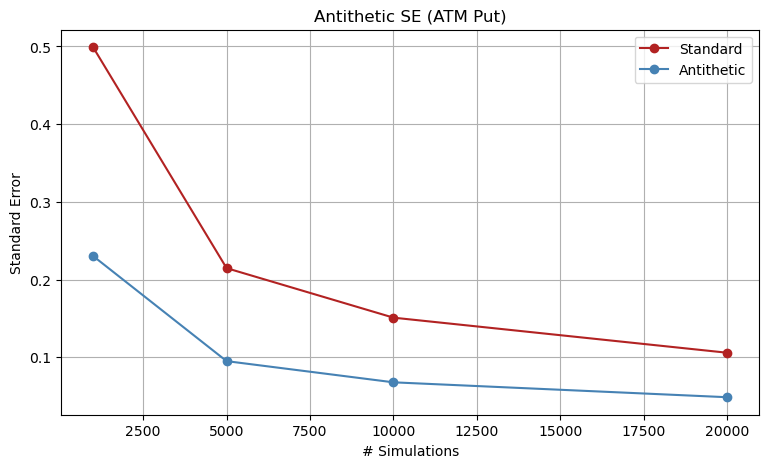

In [3]:
K_atm = 100
results_anti = []

for m in sim_counts:
    p_smc, var_smc = lsm_price(K_atm, r, T, payoff='put', S0=S0, mu=mu, sigma=sigma, m=m, n=n, antithetic=False) # Standard Monte Carlo
    p_anti, var_anti = lsm_price(K_atm, r, T, payoff='put', S0=S0, mu=mu, sigma=sigma, m=m, n=n, antithetic=True) # Antithetic sampling

    # variance calc 
    se_smc = np.sqrt(var_smc / m)
    se_anti = np.sqrt(var_anti / m) # var is alr multiplied by 2 in func so this stays simple

    results_anti.append({
        'N': m,
        'Price SMC': p_smc,
        'SE SMC': se_smc,
        'Price Anti': p_anti,
        'SE Anti': se_anti,
        'Variance Reduction': var_smc / var_anti
    })

df_anti = pd.DataFrame(results_anti)
display(df_anti)

# plot
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(df_anti['N'], df_anti['SE SMC'], 'o-', label='Standard', color='firebrick')
ax.plot(df_anti['N'], df_anti['SE Anti'], 'o-', label='Antithetic', color='steelblue')
ax.set_title('Antithetic SE (ATM Put)')
ax.set_xlabel('# Simulations')
ax.set_ylabel('Standard Error')
ax.legend()
ax.grid()
plt.show();

Note that the variance decreases significantly for each $m$ tested, with standard errors being consistently lower.

I now test the same sampling technique on an OTM put.

,N,Price SMC,SE SMC,Price Anti,SE Anti,Variance Reduction
0,1000,1.268090,0.137480,1.258837,0.126084,1.188955
1,5000,1.119237,0.050968,1.221872,0.051150,0.992928
2,10000,1.164595,0.036893,1.192759,0.036511,1.021053
3,20000,1.150577,0.026067,1.165565,0.024753,1.109048


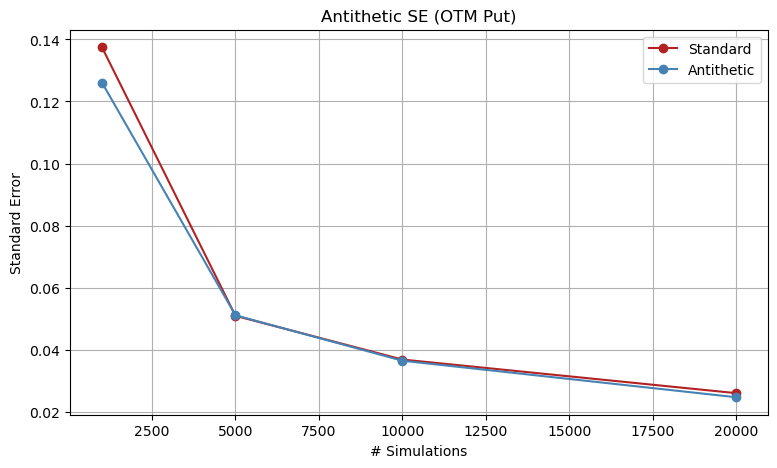

In [4]:
K_otm = 60
results_anti = []

for m in sim_counts:
    p_smc, var_smc = lsm_price(K_otm, r, T, payoff='put', S0=S0, mu=mu, sigma=sigma, m=m, n=n, antithetic=False) # Standard Monte Carlo
    p_anti, var_anti = lsm_price(K_otm, r, T, payoff='put', S0=S0, mu=mu, sigma=sigma, m=m, n=n, antithetic=True) # Antithetic sampling

    # variance calc 
    se_smc = np.sqrt(var_smc / m)
    se_anti = np.sqrt(var_anti / m) # var is alr multiplied by 2 in func so this stays simple

    results_anti.append({
        'N': m,
        'Price SMC': p_smc,
        'SE SMC': se_smc,
        'Price Anti': p_anti,
        'SE Anti': se_anti,
        'Variance Reduction': var_smc / var_anti
    })

df_anti = pd.DataFrame(results_anti)
display(df_anti)

# plot
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(df_anti['N'], df_anti['SE SMC'], 'o-', label='Standard', color='firebrick')
ax.plot(df_anti['N'], df_anti['SE Anti'], 'o-', label='Antithetic', color='steelblue')
ax.set_title('Antithetic SE (OTM Put)')
ax.set_xlabel('# Simulations')
ax.set_ylabel('Standard Error')
ax.legend()
ax.grid()
plt.show();

For a put that is deep and out of the money, the variance is barely reduced and is even increased in some cases. This is what we expect, since the payoff is near 0 for most of the path. For this, we can use importance sampling to shift more observations into the money.

,N,Price SMC,SE SMC,Price Imp,SE Imp,Variance Reduction
0,1000,1.268090,0.137480,1.145114,0.030179,20.752504
1,5000,1.119237,0.050968,1.160795,0.013683,13.875569
2,10000,1.164595,0.036893,1.155401,0.009683,14.517167
3,20000,1.150577,0.026067,1.158723,0.006857,14.450892


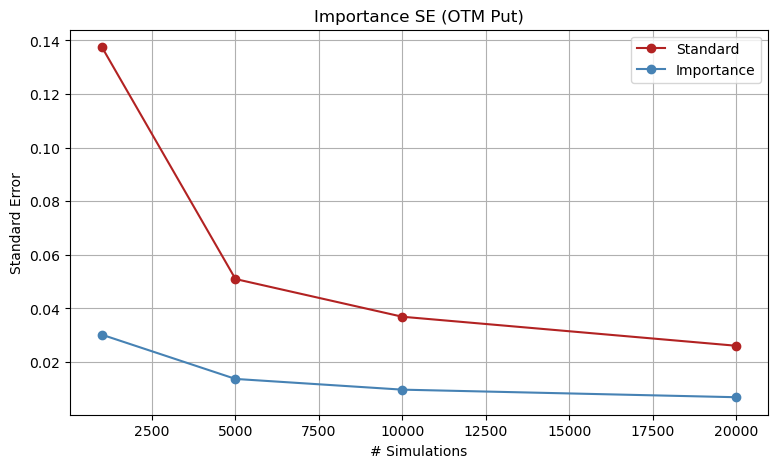

In [5]:
results_imp = []

for m in sim_counts:
    p_smc, var_smc = lsm_price(K_otm, r, T, payoff='put', S0=S0, mu=mu, sigma=sigma, m=m, n=n, importance=False) # Standard Monte Carlo
    p_imp, var_imp = lsm_price(K_otm, r, T, payoff='put', S0=S0, mu=mu, sigma=sigma, m=m, n=n, importance=True) # Importance Sampling

    # variance calc 
    se_smc = np.sqrt(var_smc / m)
    se_imp = np.sqrt(var_imp / m) 

    results_imp.append({
        'N': m,
        'Price SMC': p_smc,
        'SE SMC': se_smc,
        'Price Imp': p_imp,
        'SE Imp': se_imp,
        'Variance Reduction': var_smc / var_imp
    })

df_imp = pd.DataFrame(results_imp)
display(df_imp)

# plot
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(df_imp['N'], df_imp['SE SMC'], 'o-', label='Standard', color='firebrick')
ax.plot(df_imp['N'], df_imp['SE Imp'], 'o-', label='Importance', color='steelblue')
ax.set_title('Importance SE (OTM Put)')
ax.set_xlabel('# Simulations')
ax.set_ylabel('Standard Error')
ax.legend()
ax.grid()
plt.show();

The price estimates are much more stable now, and the variance is drastically lowered in each scenario.

### iii. Questions

* The antithetic variance reduction technique works by using dependent samples from the same distribution that have a negative covariance instead of independent samples. The variance of a sum (in general) is $Var(X+Y) = Var(X) + Var(Y) + 2Cov(X, Y)$. Normally, the covariance term is 0, but in antithetic sampling, it is negative, since for every path simulated we generate one with a negative covariance. Averaging the two works to lower the variance of the estimator through the aforementioned property of variance.
* Importance sampling reduces variance by giving more weight to the "important" parts of the distribution, specifically where there is a payoff. As we saw, most payoffs end up at zeros for an OTM option when using Standard Monte Carlo simulation. Thus, we shift the probability measure (changing the drift) so that more paths end up in the money, and then correct for this bias by multiplying the result by the likelihood ratio (the weights). It ends up having the same expectation but significantly lower variance because we sampled the rare event more frequently.
* For Deep OTM options, **importance sampling** is best. Standard MC simulation struggles because much of the payoffs are zeros, and antithetic doesn't help much either if both the path and its negative covariate result in more zeros. Importance sampling forces the simulation into the tail where there are nonzero payoffs, providing significant variance reduction. For ATM options, **antithetic sampling** is best. The option already pays off frequency, so we don't need to force paths into the money and potentially add more noise through the weights. Therefore, antithetic is more robust in this scenario.